# V7: Multi-GNN Comparison — Optuna HPO + Feature Importance

**Changes from V6:**
- Grid search (72 exhaustive) → Optuna TPE (30 smart Bayesian trials)
- Dropout range reduced: `[0.05 – 0.30]` (was 0.3-0.7)
- 6 new architectures: MOGAT, HyperTMO, RGCN, VEGN, FastHGTConv, SGNN
- Unified `forward(graph)` interface for all 7 models
- Permutation-based gene feature importance
- Attention-weight heatmaps for GAT-family models

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

# ── Tuning constants ────────────────────────────────────────────
N_TRIALS   = 30    # Optuna trials per model-pipeline (was 72 grid combos)
MAX_EPOCHS = 200
PATIENCE   = 20

Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data and Feature Columns

In [13]:
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("Data loaded. TCGA:", tcga_df.shape, "  CGGA:", cgga_df.shape)

Data loaded. TCGA: (839, 24)   CGGA: (286, 24)


## 3. Stratified 64/16/20 Splits

In [14]:
train_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)
train_df, val_df  = train_test_split(
    train_df, test_size=0.2, stratify=train_df['Grade'], random_state=42)

print(f"Train={len(train_df)}  Val={len(val_df)}  Test={len(test_df)}")
print("Train class distribution:")
print(train_df['Grade'].value_counts())

Train=536  Val=135  Test=168
Train class distribution:
Grade
0    311
1    225
Name: count, dtype: int64


## 4. Graph Construction

`construct_bipartite_heterograph` builds the Gene-Patient HeteroData.  
`get_pp_edges` lazily computes and **caches** patient-patient edges (with sampling cap) used by RGCN and SGNN.

In [15]:
_PP_CACHE: dict = {}   # id(graph) -> (pp_edge_index, pp_edge_type)


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx)
                dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    """Return (pp_edge_index, pp_edge_type) with patient-patient co-mutation edges.
    Sampling cap (max_pts per gene) prevents O(n^2) explosion for large cohorts."""
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]

    ei       = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p      = graph['Patient'].x.shape[0]

    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts  = pat_ids[mask].unique()
        n    = len(pts)
        if n < 2:
            continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n)
        dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))

    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx   = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx])
        pp_et = torch.zeros(n_p, dtype=torch.long)

    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph: HeteroData) -> HeteroData:
    return graph.to(device)

## 5. Build Shared Val / Test / CGGA Graphs

In [16]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Validation graph:", val_graph['Patient'].x.shape[0], "patients,",
      val_graph['Gene','mutates','Patient'].edge_index.shape[1], "edges")
print("Test graph:      ", test_graph['Patient'].x.shape[0], "patients,",
      test_graph['Gene','mutates','Patient'].edge_index.shape[1], "edges")
print("CGGA graph:      ", cgga_graph['Patient'].x.shape[0], "patients,",
      cgga_graph['Gene','mutates','Patient'].edge_index.shape[1], "edges")

Validation graph: 135 patients, 309 edges
Test graph:       168 patients, 401 edges
CGGA graph:       286 patients, 582 edges


## 6. Model Definitions

All 7 models share a unified `forward(graph: HeteroData)` interface.

| # | Model | Description |
|---|-------|-------------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on bipartite Gene-Patient graph |
| 2 | **MOGAT** | Multi-Omics GAT: dual genomic+clinical pathways, soft fusion gate |
| 3 | **HyperTMO** | Hypergraph convolution (patients=nodes, genes=hyperedges) |
| 4 | **RGCN** | Relational GCN on patient-patient co-mutation graph (one relation per gene) |
| 5 | **VEGN** | Variant Effect GNN with learned per-edge mutation importance weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer (HGTConv) |
| 7 | **SGNN** | Spectral GNN — Chebyshev filters on patient co-mutation adjacency |

In [17]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# ================================================================
# 1.  HeteroGATv2  (baseline — unchanged from V6)
# ================================================================
class HeteroGATv2(nn.Module):
    """Bidirectional GATv2 on bipartite Gene-Patient heterograph."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr     = dropout
        self.p_lin  = Linear(-1, hidden_dim)
        self.g_lin  = Linear(-1, hidden_dim)
        self.g2p    = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g    = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim)
        self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf    = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        hp = F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training)
        return self.clf(hp)

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p(
            (hg, hp), ei[('Gene','mutates','Patient')], return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ================================================================
# 2.  MOGAT  (Multi-Omics GAT)
# ================================================================
class MOGAT(nn.Module):
    """Dual-pathway Multi-Omics GAT.
    - Genomic path : GATv2 gene->patient message passing.
    - Clinical path: MLP on raw patient features (Age, Gender, Race).
    - Fusion       : learnable soft gate combining both paths."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr    = dropout
        # Genomic pathway
        self.pg    = Linear(-1, hidden_dim)
        self.gg    = Linear(-1, hidden_dim)
        self.gat   = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads,
                                concat=False, add_self_loops=False)
        # Clinical pathway
        self.pc    = Linear(-1, hidden_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim))
        # Fusion gate
        self.gate  = nn.Linear(hidden_dim * 2, 2)
        self.clf   = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        # Genomic path
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2),
                         self.dr, training=self.training)
        # Clinical path
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        # Soft gate
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        h   = g[:, :1] * hpg + g[:, 1:] * hpc
        return self.clf(h)


# ================================================================
# 3.  HyperTMO  (Hypergraph Tumor Multi-Omics)
# ================================================================
class HyperTMO(nn.Module):
    """Patients = graph nodes; Genes = hyperedges.
    Layer 1: attention-based HypergraphConv — gene one-hot embeddings projected
             to hidden_dim are passed as hyperedge_attr (required when
             use_attention=True in PyG HypergraphConv).
    Layer 2: standard HypergraphConv (no attention needed) + skip connection."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, **_):
        super().__init__()
        self.dr      = dropout
        self.hd      = hidden_dim
        self.p_lin   = nn.Linear(in_channels, hidden_dim)   # patient feature proj
        self.g_lin   = nn.Linear(NUM_GENES, hidden_dim)     # gene  (hyperedge) proj
        # use_attention=True: expects hyperedge_attr of shape [num_hyperedges, hidden_dim]
        self.hc1     = HypergraphConv(hidden_dim, hidden_dim,
                                       use_attention=True, heads=num_heads,
                                       dropout=dropout, concat=False)
        self.hc2     = HypergraphConv(hidden_dim, hidden_dim)
        self.skip    = nn.Linear(hidden_dim, hidden_dim)
        self.bn      = nn.BatchNorm1d(hidden_dim)
        self.clf     = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp  = graph['Patient'].x                                  # [n_pat, 3]
        xg  = graph['Gene'].x                                     # [n_genes, n_genes]
        ei  = graph[('Gene','mutates','Patient')].edge_index      # [2, E]: [gene, patient]
        # HypergraphConv expects: row-0 = node (patient), row-1 = hyperedge (gene)
        hei = torch.stack([ei[1], ei[0]], dim=0)                  # [2, E]

        hp  = F.relu(self.p_lin(xp))                              # [n_pat, hd]
        hg  = F.relu(self.g_lin(xg))                              # [n_genes, hd] -- hyperedge attrs
        s   = self.skip(hp)

        # Layer 1 (with attention): pass gene embeddings as hyperedge_attr
        hp  = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp  = F.dropout(hp, self.dr, training=self.training)

        # Layer 2 (no attention): plain aggregation + skip
        hp  = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ================================================================
# 4.  RGCN  (Relational Graph Convolutional Network)
# ================================================================
class RGCNModel(nn.Module):
    """Patient-patient co-mutation graph with 20 gene-specific relation types.
    Each (patient_i, patient_j, gene_g) triple adds a typed directed edge.
    Sampling cap avoids O(n^2) edge explosion."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr   = dropout
        self.lin  = nn.Linear(in_channels, hidden_dim)
        self.rc1  = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2  = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn   = nn.BatchNorm1d(hidden_dim)
        self.clf  = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp        = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei     = pp_ei.to(xp.device)
        pp_et     = pp_et.to(xp.device)
        h         = F.relu(self.lin(xp))
        s         = self.skip(h)
        h         = F.relu(self.rc1(h, pp_ei, pp_et))
        h         = F.dropout(h, self.dr, training=self.training)
        h         = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ================================================================
# 5.  VEGN  (Variant Effect Graph Network)
# ================================================================
class VEGNModel(nn.Module):
    """Learns per-edge variant-effect importance weights.
    A small MLP maps concat(h_gene, h_patient) -> scalar edge weight.
    Weighted mean aggregation replaces uniform sum in standard GCN."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr    = dropout
        self.p_lin = Linear(-1, hidden_dim)
        self.g_lin = Linear(-1, hidden_dim)
        # variant-effect scorer
        self.ve    = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1), nn.Sigmoid())
        # reverse refinement
        self.p2g   = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads,
                                concat=False, add_self_loops=False)
        self.skip  = Linear(hidden_dim, hidden_dim)
        self.bn    = nn.BatchNorm1d(hidden_dim)
        self.clf   = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x;  xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index

        hp = F.relu(self.p_lin(xp))
        hg = F.relu(self.g_lin(xg))

        sg, dp = e_g2p[0], e_g2p[1]
        wt  = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)  # [E]
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp)
        agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt);  deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)

        # Patient->Gene reverse refinement (unused in classification but stabilises training)
        _ = self.p2g((hp, hg), e_p2g)

        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ================================================================
# 6.  FastHGTConv  (Fast Heterogeneous Graph Transformer)
# ================================================================
_HGT_META = (
    ['Patient', 'Gene'],
    [('Gene','mutates','Patient'), ('Patient','mutated_by','Gene')]
)

class FastHGTModel(nn.Module):
    """Two-layer Heterogeneous Graph Transformer (HGTConv).
    Type-conditioned attention learns distinct query/key/value transforms
    for each node-type pair and edge type."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr    = dropout
        self.p_lin = Linear(-1, hidden_dim)
        self.g_lin = Linear(-1, hidden_dim)
        self.hgt1  = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.hgt2  = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.skip  = Linear(hidden_dim, hidden_dim)
        self.bn    = nn.BatchNorm1d(hidden_dim)
        self.clf   = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd  = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
               'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp  = self.skip(xd['Patient'])
        ei  = graph.edge_index_dict
        xd  = {k: F.dropout(F.relu(v), self.dr, training=self.training)
               for k, v in self.hgt1(xd, ei).items()}
        xd  = self.hgt2(xd, ei)
        hp  = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ================================================================
# 7.  SGNN  (Spectral / Synolitical GNN)
# ================================================================
class SGNNModel(nn.Module):
    """Chebyshev spectral convolution (K=3) on patient co-mutation adjacency.
    Bipartite graph is projected to a patient-patient graph (shared mutations = edges);
    ChebConv applies polynomial graph filters in the spectral domain."""
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr   = dropout
        self.lin  = nn.Linear(in_channels, hidden_dim)
        self.c1   = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2   = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1  = nn.BatchNorm1d(hidden_dim)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.clf  = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp       = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph)
        pp_ei    = pp_ei.to(xp.device)
        h  = F.relu(self.lin(xp))
        s  = self.skip(h)
        h  = self.bn1(F.relu(self.c1(h, pp_ei)))
        h  = F.dropout(h, self.dr, training=self.training)
        h  = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Model Registry ──────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Class Weights

In [18]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts   = train_df['Grade'].value_counts()
penalty  = counts.max() / counts.min()
cw       = torch.tensor([1.0, float(penalty)], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.3f}]")

Class weights: [1.0, 1.382]


## 8. Unified Training Function

In [19]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Train with CosineAnnealingLR + early stopping; return (best_val_auc, best_state, history)."""
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw:
        kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)

    # Trigger lazy Linear(-1,...) initialisation
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                             lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
            auc = roc_auc_score(vl, vp)
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience:
                break

    return best_auc, best_state, history

## 9. Optuna Automatic HPO

Replaces exhaustive grid search with **Tree-structured Parzen Estimator (TPE)** — a Bayesian optimisation strategy that focuses trials on the most promising hyperparameter regions.

**Reduced dropout range:** `[0.05, 0.30]` (step 0.05) instead of the old `[0.3, 0.5, 0.7]`.

In [20]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Run Optuna TPE and return (best_params, best_state, study)."""

    def objective(trial):
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        val_auc, _, _ = train_and_evaluate(
            train_graph, val_graph, params, ModelClass, fixed_kw)
        return val_auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")

    # Retrain with best params to get the final state dict
    _, best_state, _ = train_and_evaluate(
        train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 10. Evaluation + Result Storage Helpers

In [21]:
def evaluate_model(model, graph):
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    return preds, probs, labels


def compute_metrics(preds, probs, labels):
    return dict(
        auc       = roc_auc_score(labels, probs),
        accuracy  = accuracy_score(labels, preds),
        precision = precision_score(labels, preds, zero_division=0),
        recall    = recall_score(labels, preds, zero_division=0),
        f1        = f1_score(labels, preds, zero_division=0),
    )


all_results = []   # list of dicts
all_models  = {}   # {(model_name, pipeline): trained model}
all_studies = {}   # {(model_name, pipeline): optuna study}
all_params  = {}   # {(model_name, pipeline): best_params}
PIPELINES   = ['No Balancing', 'SMOTE', 'CTGAN']

## 11. Pipeline A — No Balancing

In [23]:
print("=" * 65)
print("PIPELINE: NO BALANCING")
print("=" * 65)

train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))

for mname, MCls, fkw in MODEL_REGISTRY:
    print(f"\n  -- {mname} --")
    bp, state, study = run_optuna(train_nb_graph, val_graph, MCls, fkw,
                                   label=f"{mname}/NoBal")

    # Rebuild final model with best params
    kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
          'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
    kw.update(fkw)
    model = MCls(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_nb_graph)
    except: pass
    model.load_state_dict(state)

    pdt, pbt, lbt = evaluate_model(model, test_graph)
    pdc, pbc, lbc = evaluate_model(model, cgga_graph)
    mt, mc = compute_metrics(pdt, pbt, lbt), compute_metrics(pdc, pbc, lbc)
    print(f"  TCGA-Test AUC={mt['auc']:.4f}  CGGA AUC={mc['auc']:.4f}")

    for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc, pbc, lbc)]:
        rec = {'Model': mname, 'Pipeline': 'No Balancing', 'Dataset': ds,
               'probs': p, 'labels': l}
        rec.update(m); all_results.append(rec)
    all_models[(mname, 'No Balancing')]  = model
    all_studies[(mname, 'No Balancing')] = study
    all_params[(mname, 'No Balancing')]  = bp

print("\n[No Balancing] Done.")

PIPELINE: NO BALANCING

  -- HeteroGATv2 --


Best trial: 13. Best value: 0.938147: 100%|██████████| 30/30 [00:23<00:00,  1.26it/s]


  [HeteroGATv2/NoBal] Best AUC=0.9381  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.004414973500475086, 'weight_decay': 0.0003434812724461582}
  TCGA-Test AUC=0.9173  CGGA AUC=0.7621

  -- MOGAT --


Best trial: 28. Best value: 0.943095: 100%|██████████| 30/30 [00:17<00:00,  1.70it/s]


  [MOGAT/NoBal] Best AUC=0.9431  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.00589298605046412, 'weight_decay': 0.00021165344082691765}
  TCGA-Test AUC=0.9090  CGGA AUC=0.7588

  -- HyperTMO --


...

  [VEGN/NoBal] Best AUC=0.9404  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.002511344607767282, 'weight_decay': 0.00015184032691999304}
  TCGA-Test AUC=0.9051  CGGA AUC=0.6950

  -- FastHGTConv --


Best trial: 18. Best value: 0.940846: 100%|██████████| 30/30 [00:57<00:00,  1.93s/it]


  [FastHGTConv/NoBal] Best AUC=0.9408  params={'hidden_dim': 32, 'num_heads': 4, 'dropout': 0.05, 'lr': 0.009363383180174059, 'weight_decay': 0.00043746620268146993}
  TCGA-Test AUC=0.9178  CGGA AUC=0.7087

  -- SGNN --


Best trial: 22. Best value: 0.908457: 100%|██████████| 30/30 [00:14<00:00,  2.07it/s]


  [SGNN/NoBal] Best AUC=0.9085  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.002431586418187061, 'weight_decay': 0.0006973539886484832}
  TCGA-Test AUC=0.8638  CGGA AUC=0.6812

[No Balancing] Done.


## 12. Pipeline B — SMOTE

In [24]:
print("=" * 65)
print("PIPELINE: SMOTE")
print("=" * 65)

feat_cols = gene_columns + ['Gender', 'Race', 'Age_at_diagnosis']
cat_idx   = [i for i, c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]

smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols)
train_smote_df['Grade'] = yr
for c in gene_columns:
    train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE class distribution:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))

for mname, MCls, fkw in MODEL_REGISTRY:
    print(f"\n  -- {mname} --")
    bp, state, study = run_optuna(train_sm_graph, val_graph, MCls, fkw,
                                   label=f"{mname}/SMOTE")

    kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
          'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
    kw.update(fkw)
    model = MCls(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_sm_graph)
    except: pass
    model.load_state_dict(state)

    pdt, pbt, lbt = evaluate_model(model, test_graph)
    pdc, pbc, lbc = evaluate_model(model, cgga_graph)
    mt, mc = compute_metrics(pdt, pbt, lbt), compute_metrics(pdc, pbc, lbc)
    print(f"  TCGA-Test AUC={mt['auc']:.4f}  CGGA AUC={mc['auc']:.4f}")

    for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc, pbc, lbc)]:
        rec = {'Model': mname, 'Pipeline': 'SMOTE', 'Dataset': ds,
               'probs': p, 'labels': l}
        rec.update(m); all_results.append(rec)
    all_models[(mname, 'SMOTE')]  = model
    all_studies[(mname, 'SMOTE')] = study
    all_params[(mname, 'SMOTE')]  = bp

print("\n[SMOTE] Done.")

PIPELINE: SMOTE
SMOTE class distribution:
 Grade
0    311
1    311
Name: count, dtype: int64

  -- HeteroGATv2 --


Best trial: 17. Best value: 0.932074: 100%|██████████| 30/30 [00:20<00:00,  1.43it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9321  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.004382797897938865, 'weight_decay': 0.00015332890488030184}
  TCGA-Test AUC=0.9125  CGGA AUC=0.7257

  -- MOGAT --


Best trial: 20. Best value: 0.933423: 100%|██████████| 30/30 [00:11<00:00,  2.61it/s]


  [MOGAT/SMOTE] Best AUC=0.9334  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.006086041283807608, 'weight_decay': 0.0001508040880305879}
  TCGA-Test AUC=0.9181  CGGA AUC=0.7239

  -- HyperTMO --


...

  [VEGN/SMOTE] Best AUC=0.9366  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.004089642341162666, 'weight_decay': 9.133610788630916e-05}
  TCGA-Test AUC=0.9087  CGGA AUC=0.7215

  -- FastHGTConv --


Best trial: 10. Best value: 0.937247: 100%|██████████| 30/30 [01:08<00:00,  2.29s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9372  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.008115044874888285, 'weight_decay': 0.0002012487082975096}
  TCGA-Test AUC=0.9115  CGGA AUC=0.7261

  -- SGNN --


Best trial: 0. Best value: 0.903734: 100%|██████████| 30/30 [00:18<00:00,  1.58it/s]


  [SGNN/SMOTE] Best AUC=0.9037  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0015930522616241021, 'weight_decay': 0.0002607024758370766}
  TCGA-Test AUC=0.8650  CGGA AUC=0.5825

[SMOTE] Done.


## 13. Pipeline C — CTGAN

In [26]:
print("=" * 65)
print("PIPELINE: CTGAN")
print("=" * 65)

meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond  = Condition(num_rows=n_need, column_values={'Grade': min_c})
syn_s = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN class distribution:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))

for mname, MCls, fkw in MODEL_REGISTRY:
    print(f"\n  -- {mname} --")
    bp, state, study = run_optuna(train_ct_graph, val_graph, MCls, fkw,
                                   label=f"{mname}/CTGAN")

    kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
          'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
    kw.update(fkw)
    model = MCls(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_ct_graph)
    except: pass
    model.load_state_dict(state)

    pdt, pbt, lbt = evaluate_model(model, test_graph)
    pdc, pbc, lbc = evaluate_model(model, cgga_graph)
    mt, mc = compute_metrics(pdt, pbt, lbt), compute_metrics(pdc, pbc, lbc)
    print(f"  TCGA-Test AUC={mt['auc']:.4f}  CGGA AUC={mc['auc']:.4f}")

    for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc, pbc, lbc)]:
        rec = {'Model': mname, 'Pipeline': 'CTGAN', 'Dataset': ds,
               'probs': p, 'labels': l}
        rec.update(m); all_results.append(rec)
    all_models[(mname, 'CTGAN')]  = model
    all_studies[(mname, 'CTGAN')] = study
    all_params[(mname, 'CTGAN')]  = bp

print("\n[CTGAN] Done. All 21 combinations complete.")

PIPELINE: CTGAN
Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 543.06it/s]


CTGAN class distribution:
 Grade
0    311
1    311
Name: count, dtype: int64

  -- HeteroGATv2 --


Best trial: 21. Best value: 0.937922: 100%|██████████| 30/30 [00:24<00:00,  1.20it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9379  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0020667990546452816, 'weight_decay': 1.0429703713411199e-05}
  TCGA-Test AUC=0.9261  CGGA AUC=0.8024

  -- MOGAT --


...

  [VEGN/CTGAN] Best AUC=0.9384  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.0023113006643680316, 'weight_decay': 0.0006284751507001911}
  TCGA-Test AUC=0.9160  CGGA AUC=0.7366

  -- FastHGTConv --


Best trial: 25. Best value: 0.937472: 100%|██████████| 30/30 [00:49<00:00,  1.65s/it]


  [FastHGTConv/CTGAN] Best AUC=0.9375  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.005899465567822041, 'weight_decay': 0.0003942589548224868}
  TCGA-Test AUC=0.9235  CGGA AUC=0.7627

  -- SGNN --


Best trial: 11. Best value: 0.905758: 100%|██████████| 30/30 [00:16<00:00,  1.86it/s]


  [SGNN/CTGAN] Best AUC=0.9058  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.007832921114568405, 'weight_decay': 0.00022200851601376982}
  TCGA-Test AUC=0.8770  CGGA AUC=0.7757

[CTGAN] Done. All 21 combinations complete.


## 14. Comprehensive Results Table

In [27]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('probs','labels')}
    for r in all_results
])
for c in ['auc','accuracy','precision','recall','f1']:
    results_df[c] = results_df[c].round(4)
results_df.columns = [c.capitalize() if c not in ('auc','f1') else c.upper()
                       for c in results_df.columns]
results_df.rename(columns={'Model':'Model','Pipeline':'Pipeline',
                             'Dataset':'Dataset'}, inplace=True)
# tidy column names
results_df.columns = ['Model','Pipeline','Dataset','AUC','Accuracy','Precision','Recall','F1']

print("\n" + "="*95)
print("FULL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*95)
print(results_df.to_string(index=False))

print("\n--- Top-5 by AUC on TCGA Test ---")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)[['Model','Pipeline','AUC','F1']]
      .to_string(index=False))

print("\n--- Top-5 by AUC on CGGA ---")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)[['Model','Pipeline','AUC','F1']]
      .to_string(index=False))


FULL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset    AUC  Accuracy  Precision  Recall     F1
HeteroGATv2 No Balancing TCGA Test 0.9198    0.8452     0.7683  0.9000 0.8289
HeteroGATv2 No Balancing      CGGA 0.7441    0.5804     0.4531  0.8529 0.5918
      MOGAT No Balancing TCGA Test 0.9294    0.8690     0.7927  0.9286 0.8553
      MOGAT No Balancing      CGGA 0.7661    0.6853     0.5411  0.7745 0.6371
   HyperTMO No Balancing TCGA Test 0.8289    0.7500     0.6556  0.8429 0.7375
   HyperTMO No Balancing      CGGA 0.7097    0.4301     0.3755  0.9020 0.5303
HeteroGATv2 No Balancing TCGA Test 0.9173    0.8512     0.7848  0.8857 0.8322
HeteroGATv2 No Balancing      CGGA 0.7621    0.6329     0.4909  0.7941 0.6067
      MOGAT No Balancing TCGA Test 0.9090    0.8452     0.7683  0.9000 0.8289
      MOGAT No Balancing      CGGA 0.7588    0.6084     0.4722  0.8333 0.6028
   HyperTMO No Balancing TCGA Test 0.8217    0.7440     0.6667  0.7714 0.7152
   HyperTMO 

## 15. AUC Heatmaps — Model × Pipeline

ValueError: Index contains duplicate entries, cannot reshape

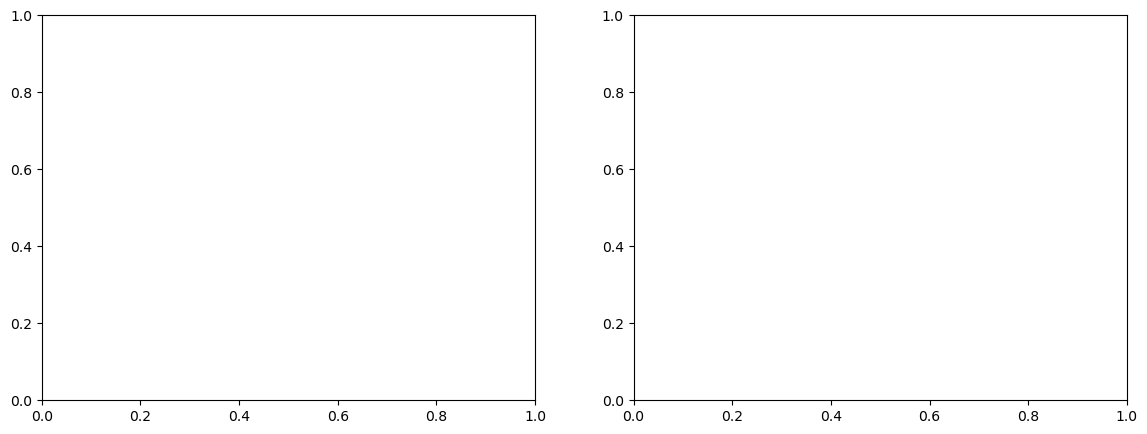

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    pivot = (results_df[results_df.Dataset == ds]
             .pivot(index='Model', columns='Pipeline', values='AUC')
             [['No Balancing', 'SMOTE', 'CTGAN']])
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × All Pipelines', fontsize=14)
plt.tight_layout()
plt.savefig('V7_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. ROC Curve Grid

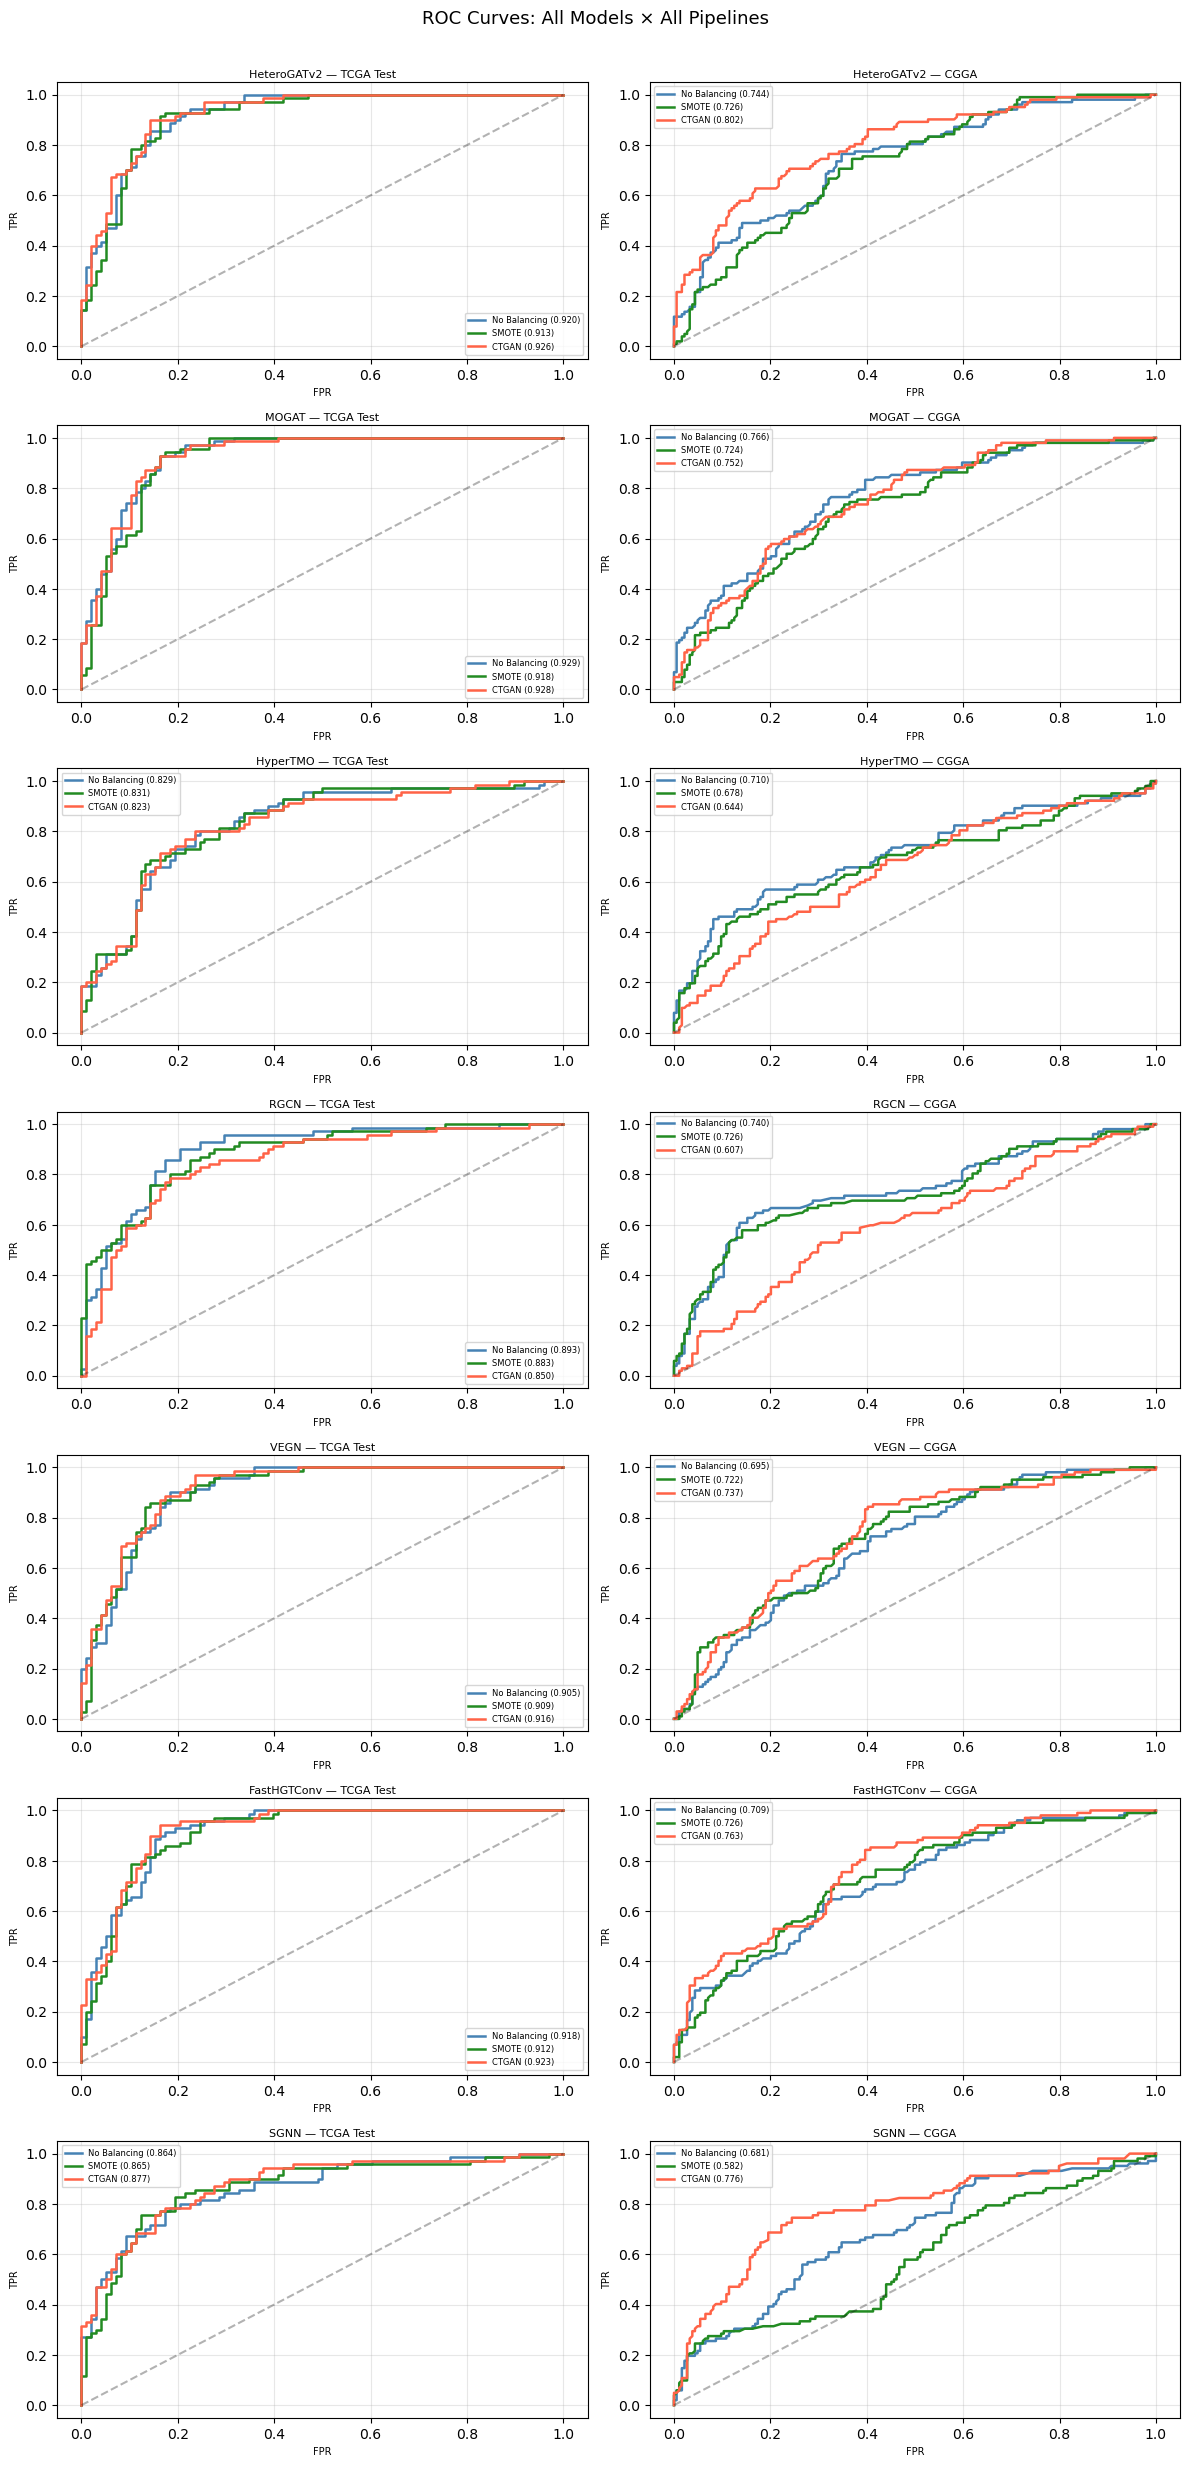

In [29]:
model_names = [n for n, _, _ in MODEL_REGISTRY]
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}
results_full = pd.DataFrame(all_results)  # includes probs & labels

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model == mname) &
                                (results_full.Pipeline == pipe) &
                                (results_full.Dataset  == ds)]
            if sub.empty: continue
            fpr, tpr, _ = roc_curve(sub.iloc[0]['labels'], sub.iloc[0]['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} ({sub.iloc[0]['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8, pad=3)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: All Models × All Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V7_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Per-Pipeline Metric Comparison

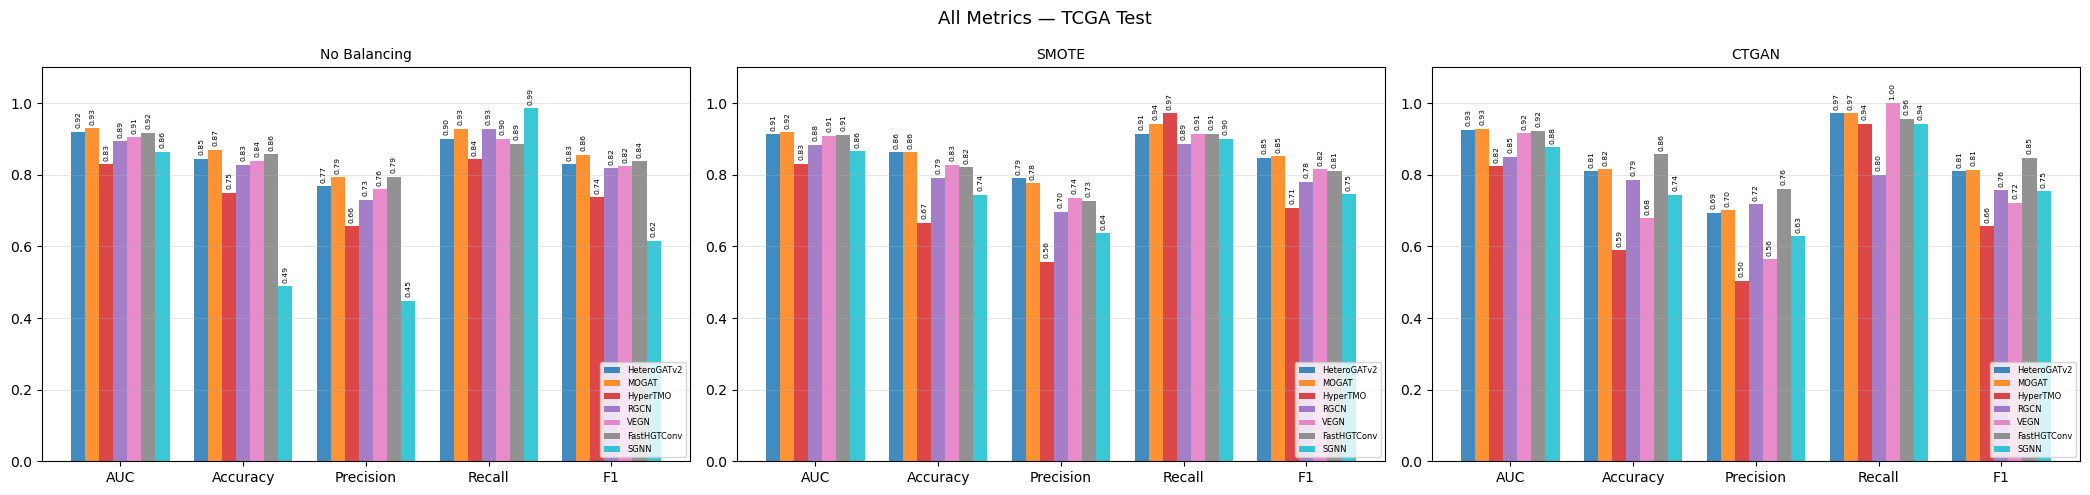

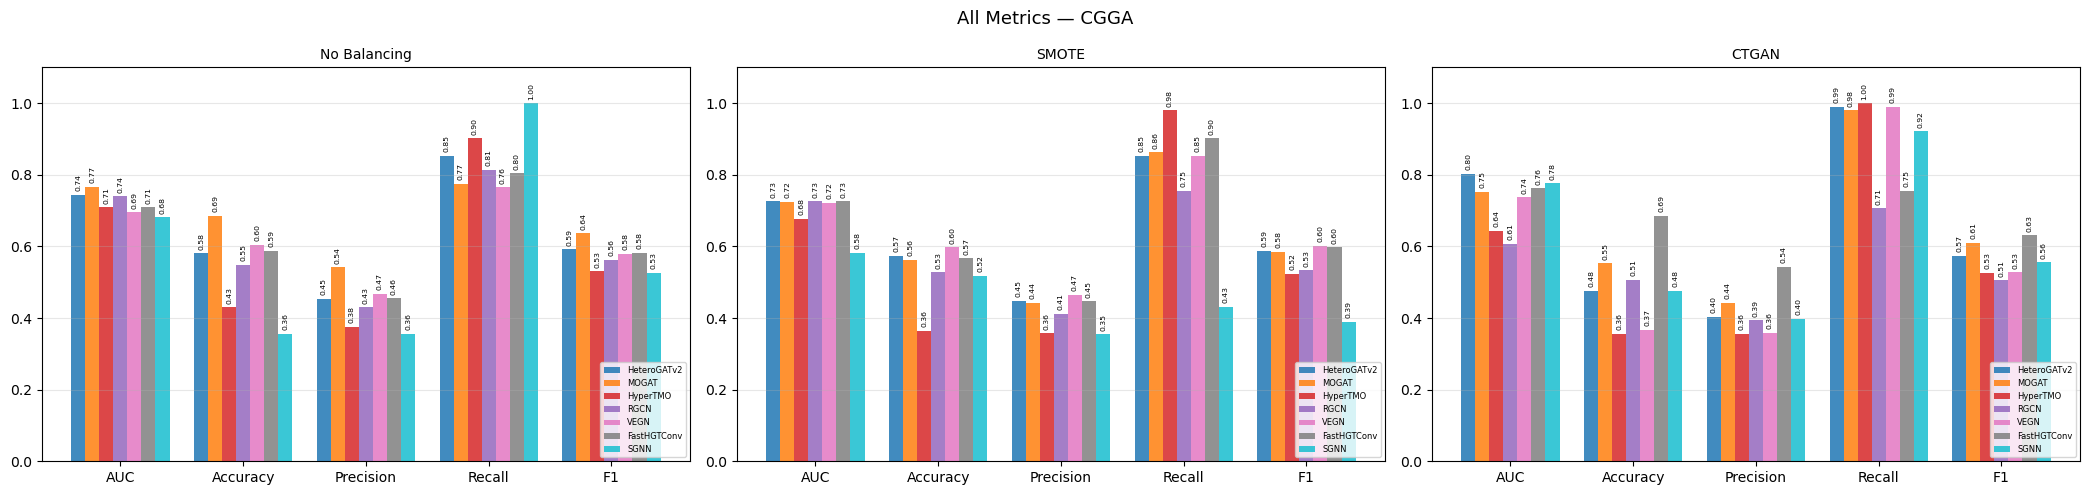

In [30]:
metric_cols = ['AUC','Accuracy','Precision','Recall','F1']
cm_list = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))

for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    for pi, pipe in enumerate(PIPELINES):
        ax = axes[pi]
        sub = results_df[(results_df.Dataset==ds) & (results_df.Pipeline==pipe)]
        x   = np.arange(len(metric_cols))
        w   = 0.8 / len(model_names)
        for mi, mname in enumerate(model_names):
            row = sub[sub.Model==mname]
            if row.empty: continue
            vals   = [row.iloc[0][c] for c in metric_cols]
            offset = (mi - len(model_names)/2)*w + w/2
            bars   = ax.bar(x+offset, vals, w, label=mname,
                             color=cm_list[mi], alpha=0.85)
            for b, v in zip(bars, vals):
                ax.text(b.get_x()+b.get_width()/2, v+0.01,
                         f'{v:.2f}', ha='center', va='bottom',
                         fontsize=5.5, rotation=90)
        ax.set_xticks(x); ax.set_xticklabels(metric_cols)
        ax.set_ylim(0, 1.1); ax.set_title(f'{pipe}', fontsize=10)
        ax.legend(fontsize=6, loc='lower right'); ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'All Metrics — {ds}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'V7_bars_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 18. Confusion Matrices (Best Model per Pipeline × Dataset)

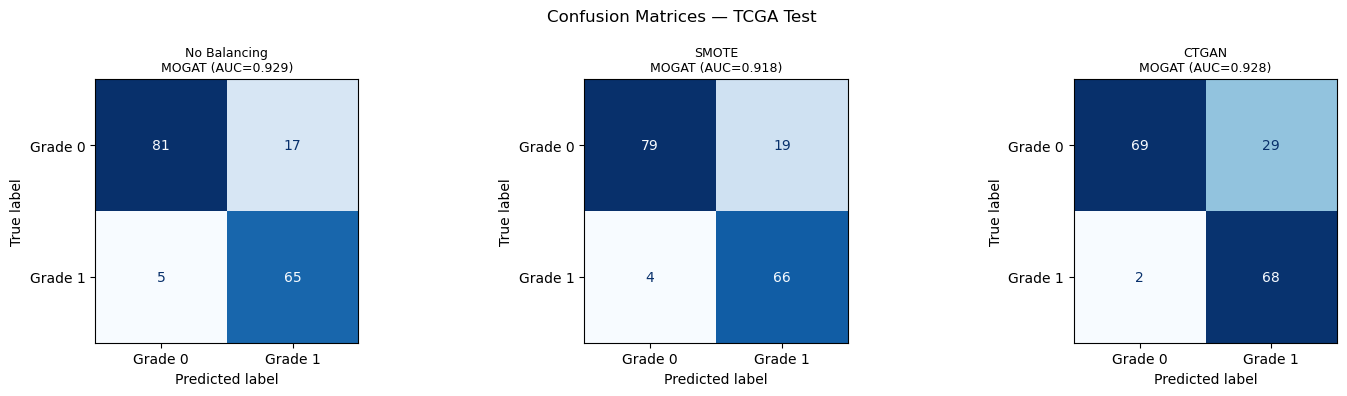

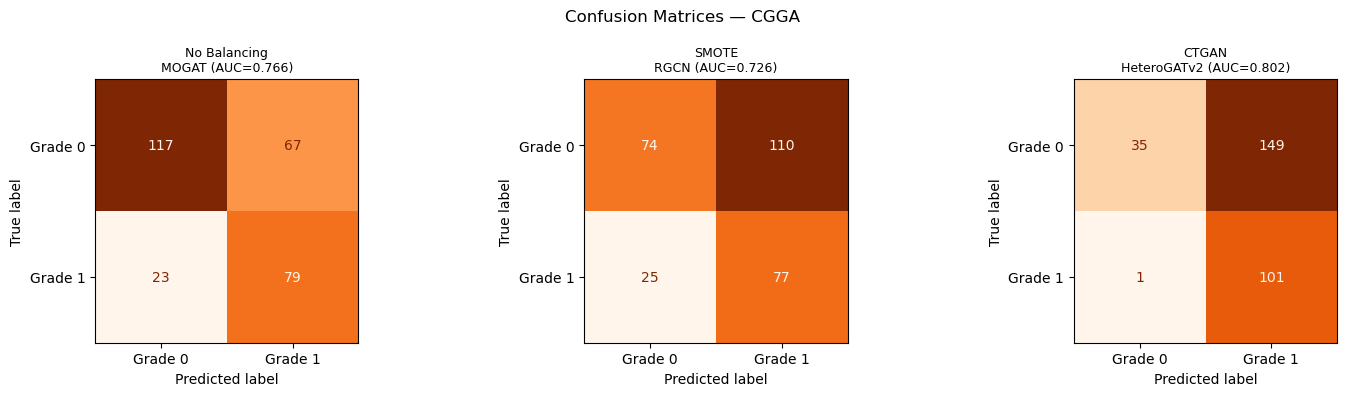

In [31]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        best = sub.loc[sub['auc'].idxmax()]
        preds = (best['probs'] >= 0.5).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f})", fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V7_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 19. Calibration Curves

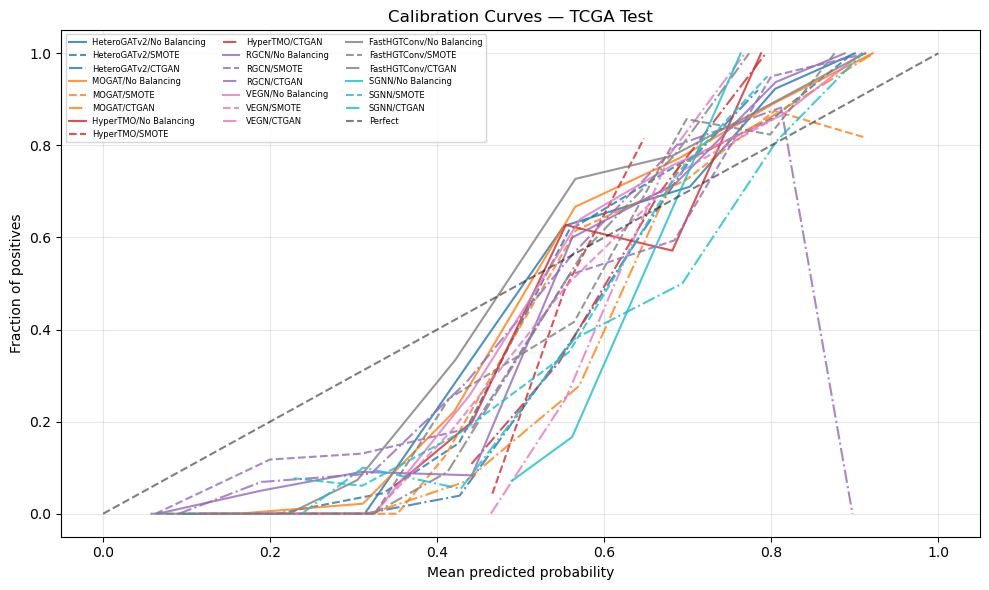

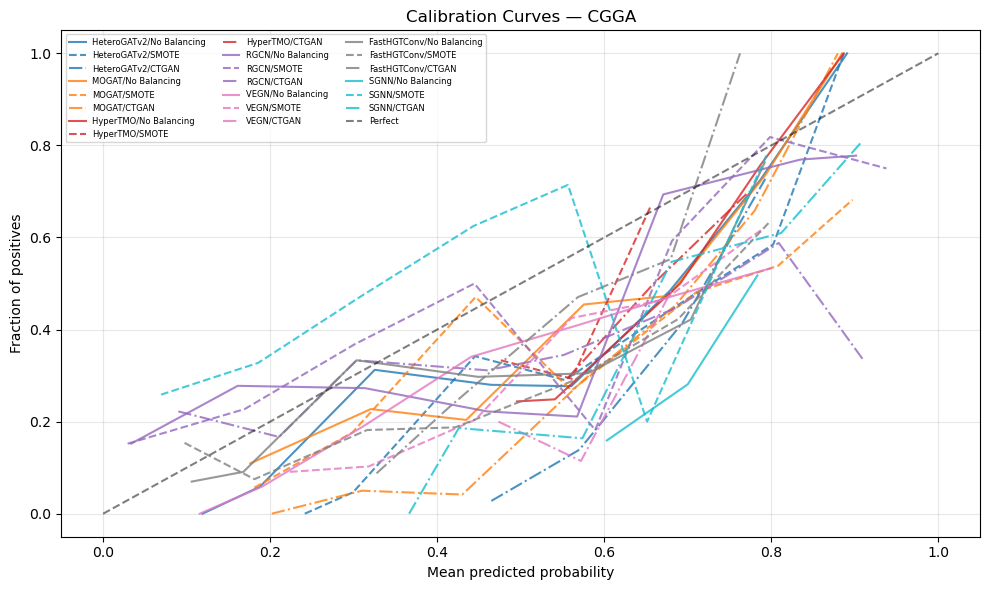

In [32]:
ls_map = {'No Balancing':'-', 'SMOTE':'--', 'CTGAN':'-.'}

for ds in ['TCGA Test','CGGA']:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_m = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
    for mi, mname in enumerate(model_names):
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            frac, mp = calibration_curve(sub.iloc[0]['labels'],
                                          sub.iloc[0]['probs'], n_bins=8)
            ax.plot(mp, frac, ls_map[pipe], color=colors_m[mi], alpha=0.8,
                    label=f"{mname}/{pipe}")
    ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration Curves — {ds}')
    ax.legend(fontsize=6, ncol=3, loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'V7_calib_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 20. Gene Feature Importance — Permutation Method

For each gene, we permute its mutation column across **all test patients** and measure AUC drop.  
- Larger drop → gene is more important  
- Averaged over `n_repeats=10` shuffles to reduce variance  
- Computed for every model × pipeline combination

In [33]:
def perm_importance(model, ref_df, n_repeats=10, seed=0):
    """Returns {gene: mean_auc_drop} for the TCGA test set."""
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    base_auc = roc_auc_score(ref_df['Grade'].values, bp)

    rng = np.random.default_rng(seed)
    out = {}
    for gene in gene_columns:
        drops = []
        for _ in range(n_repeats):
            df2 = ref_df.copy()
            df2[gene] = rng.permutation(df2[gene].values)
            g2  = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
        out[gene] = float(np.mean(drops))
    return out, base_auc


print("Computing permutation importance (10 repeats × 20 genes × 21 combinations)...")
imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        imp, base = perm_importance(model, test_df, n_repeats=10)
        for gene, drop in imp.items():
            imp_records.append({'Model': mname, 'Pipeline': pipe,
                                 'Gene': gene, 'AUC_Drop': drop,
                                 'Base_AUC': base})
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
print("\nPermutation importance computed.")

Computing permutation importance (10 repeats × 20 genes × 21 combinations)...
  HeteroGATv2/No Balancing  base=0.9173
  HeteroGATv2/SMOTE  base=0.9125
  HeteroGATv2/CTGAN  base=0.9261
  MOGAT/No Balancing  base=0.9090
  MOGAT/SMOTE  base=0.9181
  MOGAT/CTGAN  base=0.9276
  HyperTMO/No Balancing  base=0.8217
  HyperTMO/SMOTE  base=0.8313
  HyperTMO/CTGAN  base=0.8232
  RGCN/No Balancing  base=0.8933
  RGCN/SMOTE  base=0.8691
  RGCN/CTGAN  base=0.8500
  VEGN/No Balancing  base=0.9051
  VEGN/SMOTE  base=0.9087
  VEGN/CTGAN  base=0.9160
  FastHGTConv/No Balancing  base=0.9178
  FastHGTConv/SMOTE  base=0.9115
  FastHGTConv/CTGAN  base=0.9235
  SGNN/No Balancing  base=0.8638
  SGNN/SMOTE  base=0.8490
  SGNN/CTGAN  base=0.8771

Permutation importance computed.


## 21. Feature Importance Visualisations

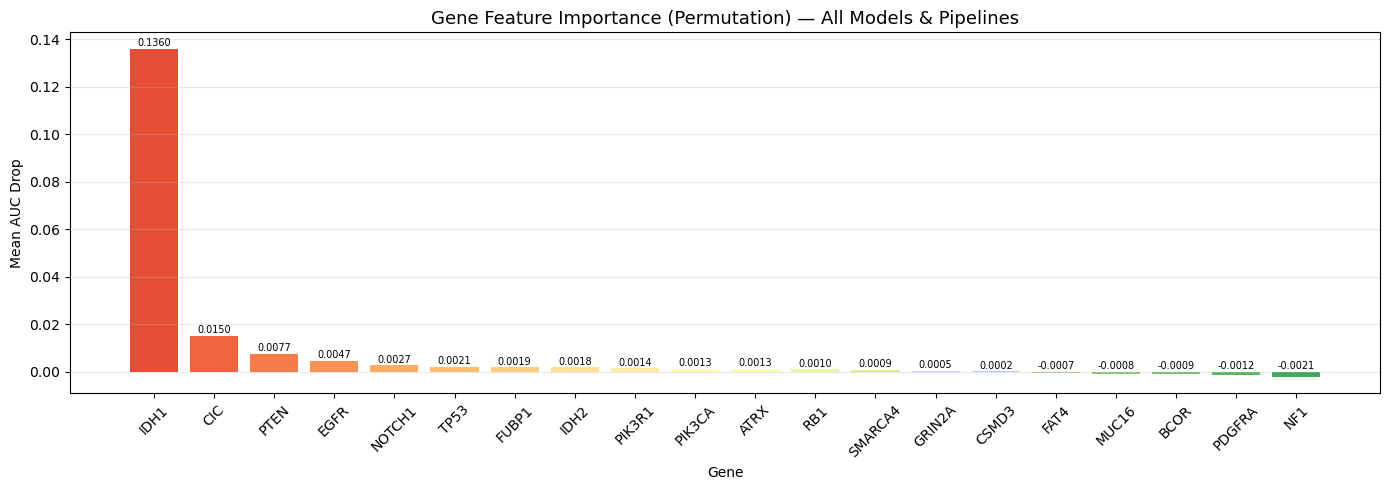

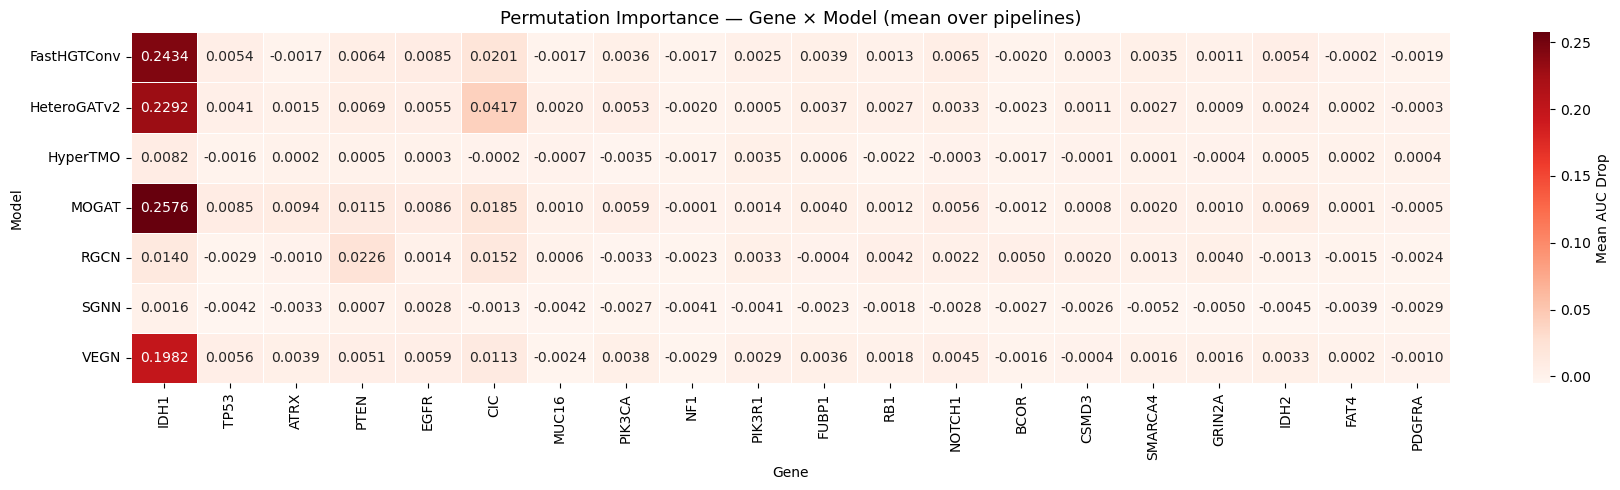

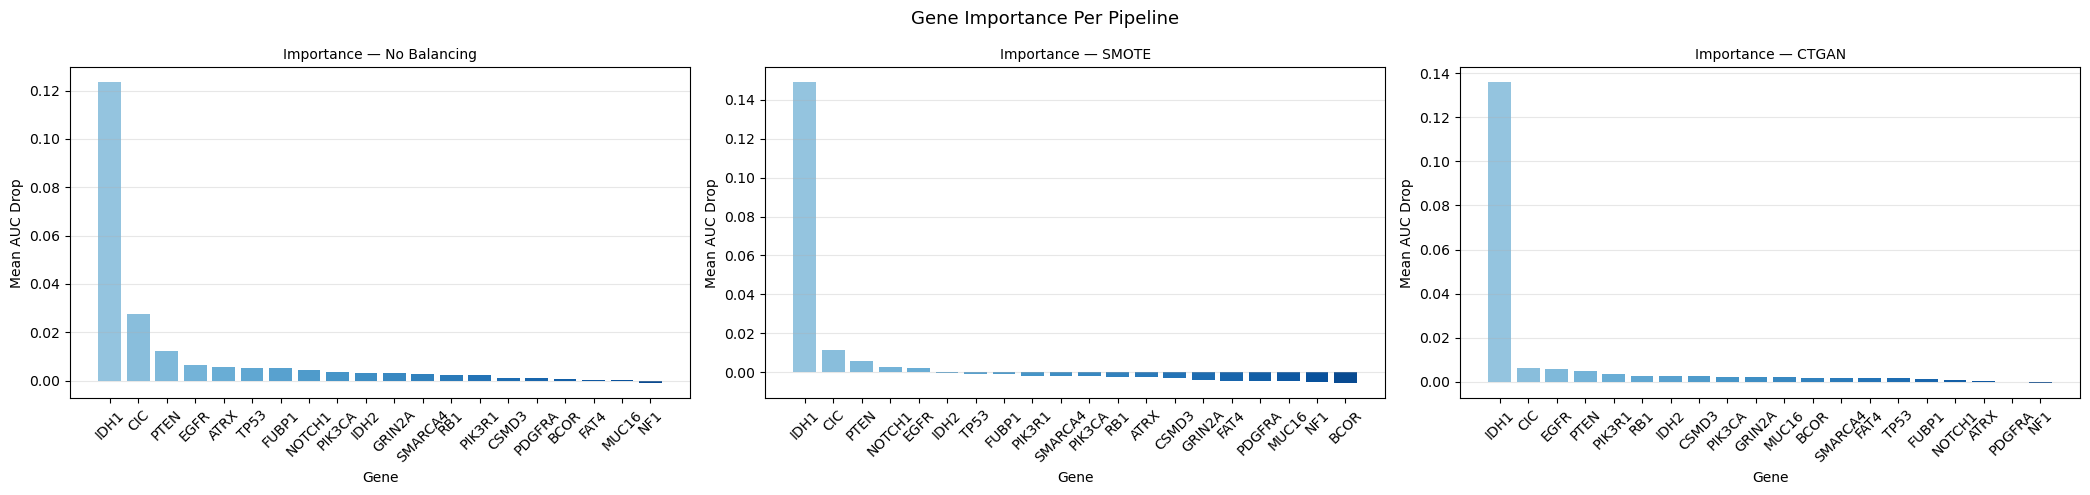


Top-5 most important genes (global):
Gene
IDH1      0.136007
CIC       0.015030
PTEN      0.007674
EGFR      0.004729
NOTCH1    0.002733


In [34]:
# ── A. Global mean importance (all models × all pipelines) ─────
mean_imp = (imp_df.groupby('Gene')['AUC_Drop']
            .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
cmap_v = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(mean_imp)))
bars   = ax.bar(mean_imp.index, mean_imp.values, color=cmap_v)
ax.set_xlabel('Gene'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Gene Feature Importance (Permutation) — All Models & Pipelines', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp.values):
    ax.text(b.get_x()+b.get_width()/2, max(v+0.0003, 0.0005),
             f'{v:.4f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('V7_feat_importance_global.png', dpi=150, bbox_inches='tight')
plt.show()

# ── B. Heatmap: Gene × Model (averaged across pipelines) ────────
heat = (imp_df.groupby(['Model','Gene'])['AUC_Drop']
        .mean().unstack('Gene')[gene_columns])

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='Reds', linewidths=0.4,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})
ax.set_title('Permutation Importance — Gene × Model (mean over pipelines)', fontsize=13)
ax.set_xlabel('Gene'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('V7_feat_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── C. Per-pipeline importance ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline==pipe]
           .groupby('Gene')['AUC_Drop'].mean()
           .sort_values(ascending=False))
    axes[pi].bar(sub.index, sub.values,
                  color=plt.cm.Blues(np.linspace(0.4, 0.9, len(sub))))
    axes[pi].set_title(f'Importance — {pipe}', fontsize=10)
    axes[pi].set_xlabel('Gene'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45); axes[pi].grid(axis='y', alpha=0.3)
plt.suptitle('Gene Importance Per Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig('V7_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop-5 most important genes (global):")
print(mean_imp.head(5).to_string())

## 22. Gene Attention Weights — HeteroGATv2 & MOGAT


Attention: HeteroGATv2 / No Balancing


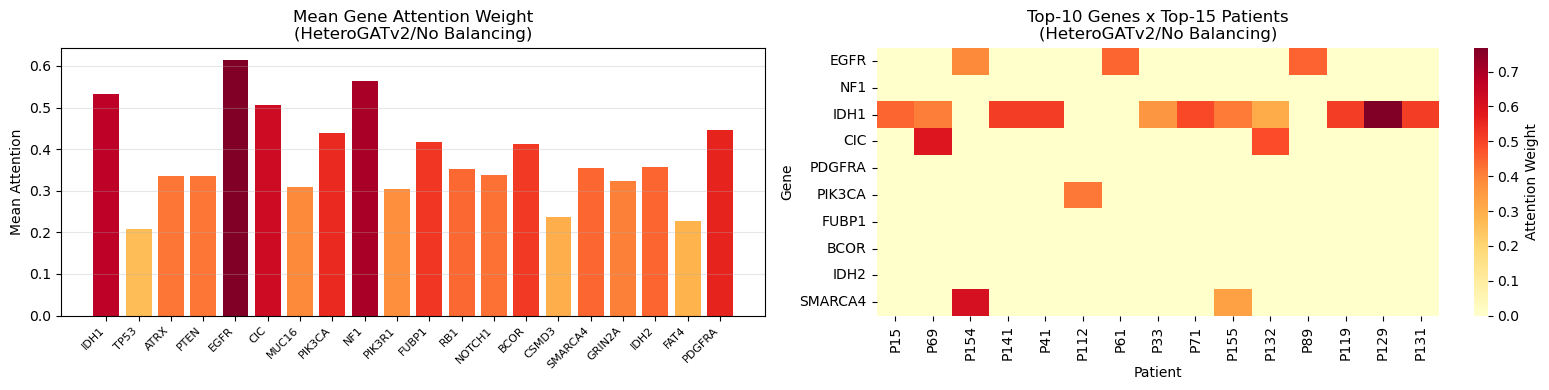


Attention: MOGAT / No Balancing
  MOGAT has no get_attn_weights — skipping.

Attention: HeteroGATv2 / SMOTE


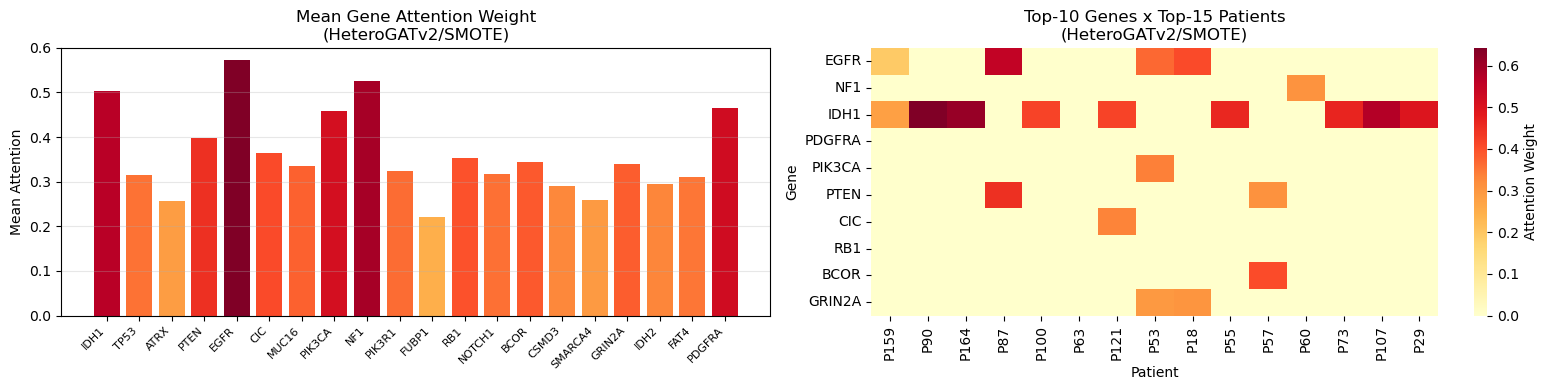


Attention: MOGAT / SMOTE
  MOGAT has no get_attn_weights — skipping.

Attention: HeteroGATv2 / CTGAN


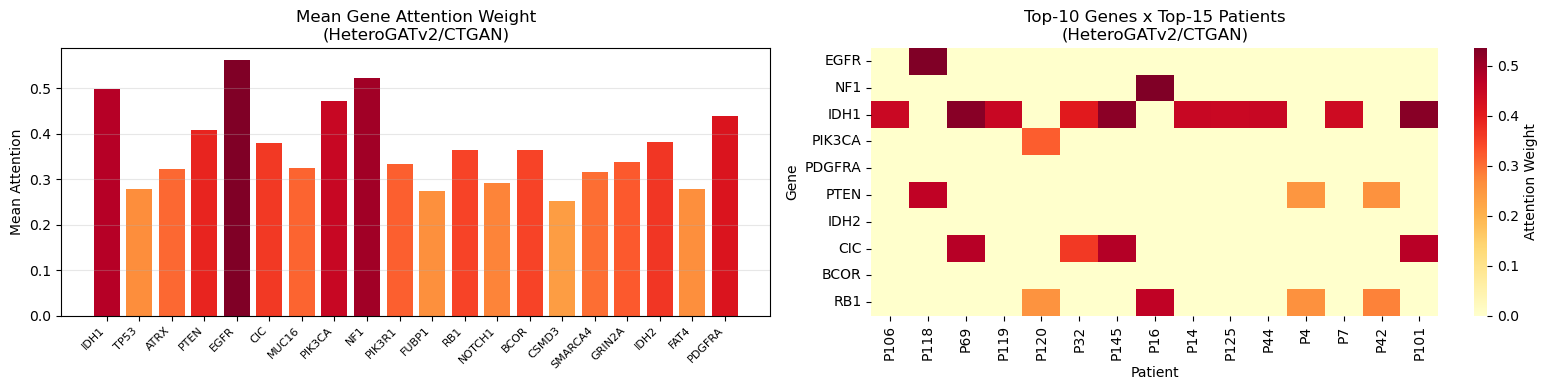


Attention: MOGAT / CTGAN
  MOGAT has no get_attn_weights — skipping.


In [35]:
def plot_gene_attention(model, graph, ref_df, title):
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention per gene
    gene_attn = np.zeros(NUM_GENES)
    gene_cnt  = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    # Bar chart
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn,
                 color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene Attention Weight\n({title})')
    axes[0].set_ylabel('Mean Attention'); axes[0].grid(axis='y', alpha=0.3)

    # Top-10 gene × top-15 patient heatmap
    pat_ids  = eidx[1].cpu().numpy()
    n_pat    = ref_df.shape[0]
    top_g    = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]
    mat   = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes x Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient'); axes[1].set_ylabel('Gene')
    plt.tight_layout()
    safe = title.replace(' ','-').replace('/','_')
    plt.savefig(f'V7_attention_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        model = all_models.get((mname, pipe))
        if model:
            print(f"\nAttention: {mname} / {pipe}")
            plot_gene_attention(model, test_graph, test_df, f"{mname}/{pipe}")

## 23. Optuna Optimisation Histories

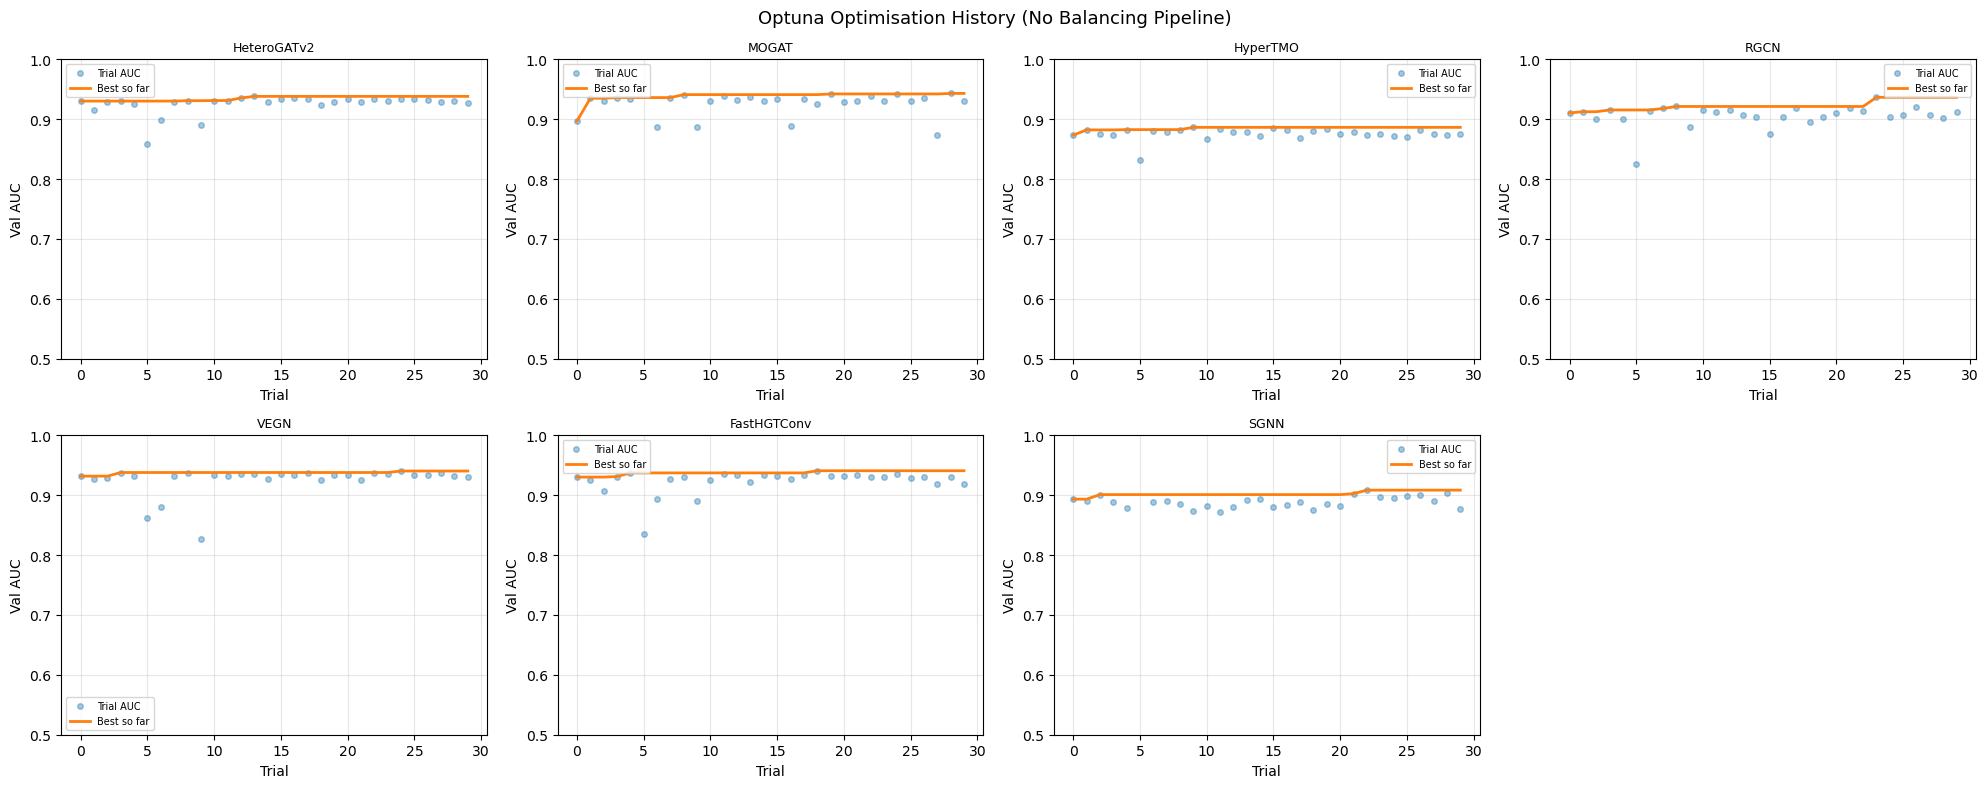

In [36]:
# Show history for each model on the No Balancing pipeline
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, (mname, _, _) in enumerate(MODEL_REGISTRY):
    study = all_studies.get((mname, 'No Balancing'))
    if study is None: continue
    ax = axes[i]
    values = [t.value for t in study.trials if t.value is not None]
    best   = [max(values[:j+1]) for j in range(len(values))]
    ax.plot(values, 'o', alpha=0.4, markersize=4, label='Trial AUC')
    ax.plot(best,   '-', lw=2, label='Best so far')
    ax.set_title(f'{mname}', fontsize=9)
    ax.set_xlabel('Trial'); ax.set_ylabel('Val AUC')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_ylim(0.5, 1.0)
if len(MODEL_REGISTRY) < len(axes):
    for j in range(len(MODEL_REGISTRY), len(axes)):
        axes[j].set_visible(False)
plt.suptitle('Optuna Optimisation History (No Balancing Pipeline)', fontsize=13)
plt.tight_layout()
plt.savefig('V7_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 24. Classification Reports — Best Models

In [37]:
for ds in ['TCGA Test','CGGA']:
    best_row = results_full[results_full.Dataset==ds].loc[
                results_full[results_full.Dataset==ds]['auc'].idxmax()]
    preds  = (best_row['probs'] >= 0.5).astype(int)
    labels = best_row['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best_row['Model']} / {best_row['Pipeline']}")
    print(f"AUC={best_row['auc']:.4f}  Accuracy={best_row['accuracy']:.4f}")
    print(classification_report(labels, preds,
                                  target_names=['Grade 0','Grade 1']))

Best on TCGA Test: MOGAT / No Balancing
AUC=0.9294  Accuracy=0.8690
              precision    recall  f1-score   support

     Grade 0       0.94      0.83      0.88        98
     Grade 1       0.79      0.93      0.86        70

    accuracy                           0.87       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.87      0.87       168

Best on CGGA: HeteroGATv2 / CTGAN
AUC=0.8024  Accuracy=0.4755
              precision    recall  f1-score   support

     Grade 0       0.97      0.19      0.32       184
     Grade 1       0.40      0.99      0.57       102

    accuracy                           0.48       286
   macro avg       0.69      0.59      0.45       286
weighted avg       0.77      0.48      0.41       286



## 25. Save Results and Models

In [ ]:
# import os
# os.makedirs('saved_models_v7', exist_ok=True)

# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v7/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

# results_df.to_csv('V7_results_summary.csv', index=False)
# imp_df.to_csv('V7_feature_importance.csv', index=False)

# # Best params table
# params_rows = [{'Model': mn, 'Pipeline': pp, **prms}
#                for (mn, pp), prms in all_params.items()]
# pd.DataFrame(params_rows).to_csv('V7_best_hyperparams.csv', index=False)

# print("Saved:")
# print("  V7_results_summary.csv")
# print("  V7_feature_importance.csv")
# print("  V7_best_hyperparams.csv")
# print("  saved_models_v7/ (21 .pth files)")
# print()
# print("Final AUC Summary:")
# pivot = results_df.pivot_table(index='Model',
#                                 columns=['Pipeline','Dataset'],
#                                 values='AUC', aggfunc='first')
# print(pivot.round(4).to_string())